In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
df = pd.read_csv("customer_churn_dataset.csv")

df.head()

,CustomerID,Age,Gender,Location,SubscriptionDurationMonths,MonthlyCharges,ContractType,PaymentMethod,OnlineSecurity,TechSupport,StreamingTV,StreamingMovies,TotalCharges,Churn
0,CUST-0001,47,Female,Chicago,36,92.36,Month-to-month,Mailed check,No,Yes,Yes,Yes,3345.61,0
1,CUST-0002,67,Female,Phoenix,47,29.28,Month-to-month,Credit card (automatic),Yes,Yes,No,No internet service,1441.35,0
2,CUST-0003,41,Female,Los Angeles,16,116.36,Month-to-month,Bank transfer (automatic),No internet service,Yes,Yes,No internet service,1913.59,1
3,CUST-0004,26,Male,Los Angeles,54,115.28,Month-to-month,Credit card (automatic),No,No,Yes,No,6230.24,1
4,CUST-0005,71,Female,Chicago,37,103.27,One year,Electronic check,No internet service,Yes,Yes,Yes,3874.93,0


In [21]:
print(df.shape)

df.info()

(650, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CustomerID                  650 non-null    object 
 1   Age                         650 non-null    int64  
 2   Gender                      650 non-null    object 
 3   Location                    650 non-null    object 
 4   SubscriptionDurationMonths  650 non-null    int64  
 5   MonthlyCharges              650 non-null    float64
 6   ContractType                650 non-null    object 
 7   PaymentMethod               650 non-null    object 
 8   OnlineSecurity              650 non-null    object 
 9   TechSupport                 650 non-null    object 
 10  StreamingTV                 650 non-null    object 
 11  StreamingMovies             650 non-null    object 
 12  TotalCharges                650 non-null    float64
 13  Churn                    

In [22]:
print(df.isnull().sum())

CustomerID                    0
Age                           0
Gender                        0
Location                      0
SubscriptionDurationMonths    0
MonthlyCharges                0
ContractType                  0
PaymentMethod                 0
OnlineSecurity                0
TechSupport                   0
StreamingTV                   0
StreamingMovies               0
TotalCharges                  0
Churn                         0
dtype: int64


In [23]:
le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == 'object':
        
        df[column] = le.fit_transform(df[column])

In [24]:
df.head()

,CustomerID,Age,Gender,Location,SubscriptionDurationMonths,MonthlyCharges,ContractType,PaymentMethod,OnlineSecurity,TechSupport,StreamingTV,StreamingMovies,TotalCharges,Churn
0,0,47,0,0,36,92.36,0,3,0,2,2,2,3345.61,0
1,1,67,0,4,47,29.28,0,1,2,2,0,1,1441.35,0
2,2,41,0,2,16,116.36,0,0,1,2,2,1,1913.59,1
3,3,26,1,2,54,115.28,0,1,0,0,2,0,6230.24,1
4,4,71,0,0,37,103.27,1,2,1,2,2,2,3874.93,0


In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [27]:
print(X.shape)
print(y.shape)

(650, 13)
(650,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(520, 13)
(130, 13)


In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [44]:
model = Sequential()

# First Hidden Layer
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))

model.add(Dropout(0.3))

# Second Hidden Layer
model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

# Third Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\patel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.compile(

    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stop = EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [47]:
history = model.fit(

    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6875 - loss: 0.6123 - val_accuracy: 0.8269 - val_loss: 0.4865
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8221 - loss: 0.4839 - val_accuracy: 0.8269 - val_loss: 0.4610
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8221 - loss: 0.4813 - val_accuracy: 0.8269 - val_loss: 0.4678
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8221 - loss: 0.4576 - val_accuracy: 0.8269 - val_loss: 0.4658
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8221 - loss: 0.4551 - val_accuracy: 0.8269 - val_loss: 0.4700
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8221 - loss: 0.4338 - val_accuracy: 0.8269 - val_loss: 0.4737
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8221 - loss: 0.4366 - val_accuracy: 0.8269 - val_loss: 0.4788


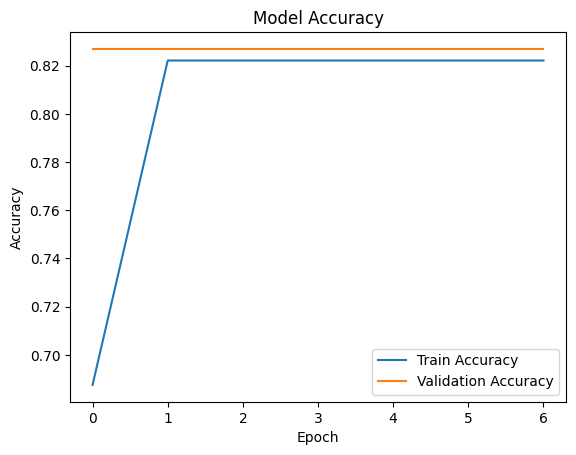

In [48]:
plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

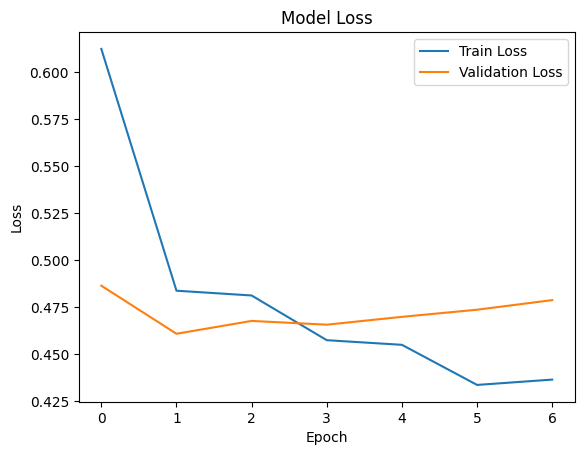

In [49]:
plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [50]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8231 - loss: 0.4622 
Test Accuracy: 0.8230769038200378


In [51]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)
y_pred = y_pred.flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [52]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       107
           1       0.00      0.00      0.00        23

    accuracy                           0.82       130
   macro avg       0.41      0.50      0.45       130
weighted avg       0.68      0.82      0.74       130



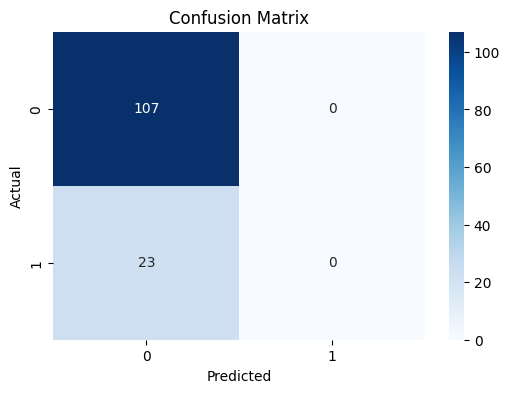

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [43]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy Score:", acc)

Accuracy Score: 0.823076923076923
